# 01 — EDA & Validation Setup

Chatbot Arena preference prediction. Target: 3-class probabilities
`[winner_model_a, winner_model_b, winner_tie]`, scored by multi-class **log loss**.

This notebook: load data, inspect schema, class balance, multi-turn structure,
text lengths, compute baseline log losses, and save reproducible stratified folds.
See `../PLAN.md` for the modeling roadmap.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
RAW = Path("../data/raw")
PROC = Path("../data/processed")
FIG = Path("../reports/figures")
PROC.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)
TARGETS = ["winner_model_a", "winner_model_b", "winner_tie"]
SEED = 42

In [2]:
train = pd.read_csv(RAW / "train.csv")
test = pd.read_csv(RAW / "test.csv")
print("train:", train.shape, "| test (visible):", test.shape)
print("train cols:", list(train.columns))
print("test  cols:", list(test.columns), "<- note: no model_a/model_b in test")
train.head(2)

train: (57477, 9) | test (visible): (3, 4)
train cols: ['id', 'model_a', 'model_b', 'prompt', 'response_a', 'response_b', 'winner_model_a', 'winner_model_b', 'winner_tie']
test  cols: ['id', 'prompt', 'response_a', 'response_b'] <- note: no model_a/model_b in test


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0


## Class balance
Targets are one-hot. Nearly uniform — so priors carry almost no information.

{'winner_model_a': 34.91, 'winner_model_b': 34.19, 'winner_tie': 30.9}


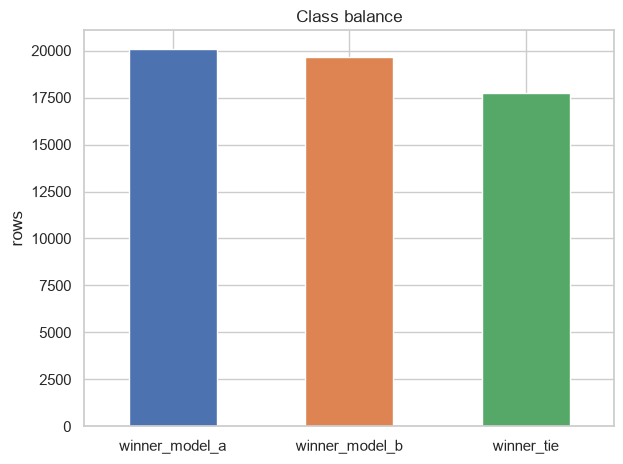

In [3]:
counts = train[TARGETS].sum()
print((train[TARGETS].mean() * 100).round(2).to_dict())
ax = counts.plot.bar(color=["#4C72B0", "#DD8452", "#55A868"], rot=0)
ax.set_title("Class balance"); ax.set_ylabel("rows")
plt.tight_layout(); plt.savefig(FIG / "q1_class_balance.png", dpi=120); plt.show()

## Multi-turn structure
`prompt` / `response_*` are JSON-encoded **lists** of turns. Most are single-turn.

In [4]:
def parse_list(x):
    try:
        v = json.loads(x)
        return v if isinstance(v, list) else [x]
    except Exception:
        return [x]

for col in ["prompt", "response_a", "response_b"]:
    train[col + "_list"] = train[col].map(parse_list)

turns = train["prompt_list"].map(len)
print(f"turns: mean {turns.mean():.2f}  median {turns.median():.0f}  "
      f"max {turns.max()}  multi-turn {100*(turns>1).mean():.1f}%")

turns: mean 1.24  median 1  max 36  multi-turn 13.1%


## Text lengths (truncation budget)
Approx tokens as chars/4. Drives `max_len` choice for transformer models.

approx total tokens: {0.5: 590.0, 0.9: 1449.0, 0.95: 1981.0, 0.99: 3785.0}


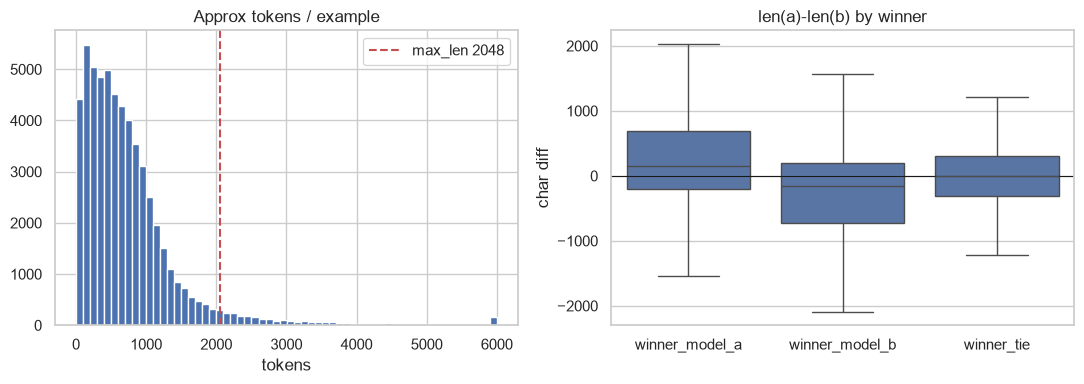

In [5]:
def char_len(lst):
    return sum(len(s) for s in lst if isinstance(s, str))

plen = train["prompt_list"].map(char_len)
alen = train["response_a_list"].map(char_len)
blen = train["response_b_list"].map(char_len)
total_tok = (plen + alen + blen) / 4.0
print("approx total tokens:",
      total_tok.quantile([.5, .9, .95, .99]).round(0).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(np.clip(total_tok, 0, 6000), bins=60, color="#4C72B0")
ax[0].axvline(2048, color="r", ls="--", label="max_len 2048"); ax[0].legend()
ax[0].set_title("Approx tokens / example"); ax[0].set_xlabel("tokens")
# length difference vs outcome: does longer answer tend to win?
ldiff = (alen - blen)
win = train[TARGETS].idxmax(axis=1)
sns.boxplot(x=win, y=np.clip(ldiff, -4000, 4000), ax=ax[1],
            order=TARGETS, showfliers=False)
ax[1].axhline(0, color="k", lw=.8); ax[1].set_title("len(a)-len(b) by winner")
ax[1].set_xlabel(""); ax[1].set_ylabel("char diff")
plt.tight_layout(); plt.savefig(FIG / "q2_lengths.png", dpi=120); plt.show()

## Baseline log losses
The number any real model must beat. Priors ≈ uniform → signal is all in the text.

In [6]:
from sklearn.metrics import log_loss

y = train[TARGETS].values
prior = train[TARGETS].mean().values
print(f"uniform (1/3)   log loss: {-np.log(1/3):.5f}")
print(f"class-prior      log loss: "
      f"{log_loss(y, np.tile(prior, (len(y), 1))):.5f}")

uniform (1/3)   log loss: 1.09861
class-prior      log loss: 1.09723


## Reproducible folds
Stratified 5-fold on the 3-class label, shared by every downstream model.

In [7]:
from sklearn.model_selection import StratifiedKFold

label = train[TARGETS].values.argmax(1)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = np.zeros(len(train), dtype=int)
for f, (_, val) in enumerate(skf.split(train, label)):
    folds[val] = f
out = train[["id"]].copy()
out["label"] = label
out["fold"] = folds
out.to_parquet(PROC / "folds.parquet", index=False)
print("saved", PROC / "folds.parquet")
print(out.groupby("fold")["label"].value_counts().unstack())

saved ../data/processed/folds.parquet
label     0     1     2
fold                   
0      4013  3931  3552
1      4013  3930  3553
2      4013  3930  3552
3      4013  3930  3552
4      4012  3931  3552
